# Setup

In [1]:
import random, numpy as np, torch
import transformers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

transformers: 5.0.0
torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## sdpa kernel test

In [2]:
from torch.nn.attention import sdpa_kernel, SDPBackend

with sdpa_kernel(SDPBackend.EFFICIENT_ATTENTION):
    q = k = v = torch.randn(1, 8, 128, 64, device="cuda", dtype=torch.float16)
    out = torch.nn.functional.scaled_dot_product_attention(q, k, v)
print("efficient sdpa OK, output shape:", out.shape)

efficient sdpa OK, output shape: torch.Size([1, 8, 128, 64])


# Download model and check its config

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "utter-project/EuroMoE-2.6B-A0.6B-2512"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   
    device_map="cuda",
)
model.eval()

cfg = model.config
print("max_position_embeddings (L_train):", cfg.max_position_embeddings)
print("rope_theta / base:", getattr(cfg, "rope_theta", None))
print("has rope_scaling:", hasattr(cfg, "rope_scaling"), getattr(cfg, "rope_scaling", None))
print("has rope_parameters:", hasattr(cfg, "rope_parameters"))

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

max_position_embeddings (L_train): 4096
rope_theta / base: None
has rope_scaling: True {'rope_theta': 500000, 'rope_type': 'default'}
has rope_parameters: True


In [4]:
print(cfg.rope_scaling is cfg.rope_parameters)
print(cfg.rope_scaling)
print(cfg.rope_parameters)

True
{'rope_theta': 500000, 'rope_type': 'default'}
{'rope_theta': 500000, 'rope_type': 'default'}


In [47]:
rotary = model.model.rotary_emb
print(type(rotary))
print("d/2 (freq pairs qty):", rotary.inv_freq.shape[0])
print("fastest freq (i=0):", rotary.inv_freq[0].item())
print("slowest freq (i=d/2-1):", rotary.inv_freq[-1].item())

<class 'transformers.models.mixtral.modeling_mixtral.MixtralRotaryEmbedding'>
d/2 (freq pairs qty): 64
fastest freq (i=0): 1.0
slowest freq (i=d/2-1): 6.137851755738666e-07


In [7]:
print("num_local_experts:", getattr(cfg, "num_local_experts", None))
print("num_experts_per_tok (top-k):", getattr(cfg, "num_experts_per_tok", None))
print("hidden_size:", cfg.hidden_size, "| num_attention_heads:", cfg.num_attention_heads, "| num_key_value_heads:", getattr(cfg, "num_key_value_heads", None))

num_local_experts: 64
num_experts_per_tok (top-k): 8
hidden_size: 1024 | num_attention_heads: 8 | num_key_value_heads: 2


# RoPE scaling

In [8]:
import torch

def compute_inv_freq(base: float, dim: int, device="cuda"):
    exponent = torch.arange(0, dim, 2, dtype=torch.float32, device=device) / dim
    return 1.0 / (base ** exponent)

def scale_inv_freq(base: float, dim: int, mode: str, s: float, device="cuda"):
    base_inv_freq = compute_inv_freq(base, dim, device)
    if mode == "none":
        return base_inv_freq
    elif mode == "position_interpolation":
        return base_inv_freq / s
    elif mode == "ntk_aware":
        new_base = base * (s ** (dim / (dim - 2)))
        return compute_inv_freq(new_base, dim, device)
    else:
        raise ValueError(f"unknown mode: {mode}")

def cos_sin_from_inv_freq(inv_freq: torch.Tensor, positions: torch.Tensor):
    freqs = torch.outer(positions.float(), inv_freq)   
    emb = torch.cat([freqs, freqs], dim=-1)             
    return emb.cos(), emb.sin()

## Tests

In [14]:
import copy
import torch
from transformers.models.mixtral.modeling_mixtral import MixtralRotaryEmbedding

BASE = 500000.0
DIM = 128
S = 4.0
THRESHOLD = 1e-5

def compute_inv_freq(base, dim, device="cuda"):
    exponent = torch.arange(0, dim, 2, dtype=torch.float32, device=device) / dim
    return 1.0 / (base ** exponent)

def scale_inv_freq(base, dim, mode, s, device="cuda"):
    base_inv_freq = compute_inv_freq(base, dim, device)
    if mode == "none":
        return base_inv_freq
    elif mode == "position_interpolation":
        return base_inv_freq / s
    elif mode == "ntk_aware":
        new_base = base * (s ** (dim / (dim - 2)))
        return compute_inv_freq(new_base, dim, device)
    else:
        raise ValueError(mode)

def hf_reference_inv_freq(rope_scaling_dict):
    ref_cfg = copy.deepcopy(cfg)
    ref_cfg.rope_scaling = rope_scaling_dict
    ref_rotary = MixtralRotaryEmbedding(config=ref_cfg).to("cuda")
    return ref_rotary.inv_freq.float()

results = {}

ours = scale_inv_freq(BASE, DIM, "none", S)
actual = model.model.rotary_emb.inv_freq.float()
results["none (vs loaded model)"] = (ours - actual).abs().max().item()

ours = scale_inv_freq(BASE, DIM, "position_interpolation", S)
ref = hf_reference_inv_freq({"rope_type": "linear", "factor": S, "rope_theta": BASE})
results["position_interpolation (vs HF linear)"] = (ours - ref).abs().max().item()

ours = scale_inv_freq(BASE, DIM, "ntk_aware", S)
i = torch.arange(0, DIM, 2, dtype=torch.float32, device="cuda") / 2
c_i = S ** (-2 * i / (DIM - 2))
expected = compute_inv_freq(BASE, DIM) * c_i
results["ntk_aware (self-check vs c_i formula)"] = (ours - expected).abs().max().item()

print(f"{'test':42s} {'max abs diff':>14s}  status")
for name, diff in results.items():
    print(f"{name:42s} {diff:14.3e}  {'OK' if diff < THRESHOLD else 'FAIL'}")

print()
print("c_0 (expected 1.0):", c_i[0].item())
print(f"c_(d/2-1) (expected 1/s={1/S}):", c_i[-1].item())

test                                         max abs diff  status
none (vs loaded model)                          2.980e-08  OK
position_interpolation (vs HF linear)           7.451e-09  OK
ntk_aware (self-check vs c_i formula)           5.960e-08  OK

c_0 (expected 1.0): 1.0
c_(d/2-1) (expected 1/s=0.25): 0.25


# Dataset

## Check dataset

In [15]:
from datasets import load_dataset

ds = load_dataset("Goader/kobza", split="train", streaming=True)
first = next(iter(ds))

print("поля:", list(first.keys()))
for k, v in first.items():
    preview = v[:300] if isinstance(v, str) else v
    print(f"{k}: {preview}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/95 [00:00<?, ?it/s]

поля: ['text', 'id', 'url', 'timestamp', 'subsource', 'source']
text: Наркоторговка з Донецька сприйняла арешт як розіграш до дня народження
Жінка пригощала гостей марихуаною © Архів
Коли в квартирі жінки з'явилися співробітники правоохоронних органів, вона в їхній присутності продала 1,2 кг марихуани.
У Ростовській області мешканку Донецька було затримано оперативник
id: hplt-2.0/d8983381ecbcee9ff6d05d5d4b0cea59
url: http://tsn.ua/tsikavinki/narkotorgovka-z-donetska-spriinyala-aresht-yak-rozigrash-do-dnya-narodzhennya.html
timestamp: 2017-01-24T09:35:52Z
subsource: ./CC-MAIN-20170116095124-00469-ip-10-171-10-70.ec2.internal.warc.3.gz
source: hplt-2.0


## Check for long documents

In [17]:
import json

MIN_TOKENS = 4 * cfg.max_position_embeddings   
CHAR_PREFILTER = 50000                          
TARGET_N_DOCS = 110                            

collected = []
n_scanned = 0
n_candidates = 0

stream = iter(ds)   

for ex in stream:
    n_scanned += 1
    if len(ex["text"]) < CHAR_PREFILTER:
        continue
    n_candidates += 1
    token_ids = tokenizer(ex["text"], truncation=False)["input_ids"]
    if len(token_ids) >= MIN_TOKENS:
        collected.append({
            "id": ex["id"],
            "url": ex.get("url"),
            "source": ex.get("source"),
            "n_chars": len(ex["text"]),
            "n_tokens": len(token_ids),
            "text": ex["text"],
        })
        print(f"[{len(collected)}/{TARGET_N_DOCS}] n_tokens={len(token_ids)}  (rows scanned: {n_scanned})")
    if len(collected) >= TARGET_N_DOCS:
        break

print(f"\nDone: {len(collected)} documents collected, {n_scanned} rows scanned, {n_candidates} passed char prefilter")

with open("/kaggle/working/eval_corpus_kobza.jsonl", "w", encoding="utf-8") as f:
    for doc in collected:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n")
print("Saved to /kaggle/working/eval_corpus_kobza.jsonl")

[1/110] n_tokens=20774  (rows scanned: 62)
[2/110] n_tokens=25806  (rows scanned: 1218)
[3/110] n_tokens=16931  (rows scanned: 3496)
[4/110] n_tokens=20658  (rows scanned: 4023)
[5/110] n_tokens=29102  (rows scanned: 4739)
[6/110] n_tokens=20252  (rows scanned: 5269)
[7/110] n_tokens=27521  (rows scanned: 5590)
[8/110] n_tokens=20088  (rows scanned: 5875)
[9/110] n_tokens=17971  (rows scanned: 5905)
[10/110] n_tokens=29491  (rows scanned: 6134)
[11/110] n_tokens=18896  (rows scanned: 7055)
[12/110] n_tokens=17298  (rows scanned: 7142)
[13/110] n_tokens=19038  (rows scanned: 7353)
[14/110] n_tokens=23180  (rows scanned: 8787)
[15/110] n_tokens=225004  (rows scanned: 8849)
[16/110] n_tokens=33080  (rows scanned: 9280)
[17/110] n_tokens=19698  (rows scanned: 9309)
[18/110] n_tokens=25962  (rows scanned: 9460)
[19/110] n_tokens=19763  (rows scanned: 9850)
[20/110] n_tokens=19777  (rows scanned: 9909)
[21/110] n_tokens=29340  (rows scanned: 12181)
[22/110] n_tokens=18640  (rows scanned: 126

## Check Corpus

In [18]:
import hashlib
from collections import Counter

with open("/kaggle/working/eval_corpus_kobza.jsonl", encoding="utf-8") as f:
    docs = [json.loads(line) for line in f]

hashes = [hashlib.sha256(d["text"].encode("utf-8")).hexdigest() for d in docs]
dup_count = len(hashes) - len(set(hashes))
print(f"Total docs: {len(docs)}, exact duplicates: {dup_count}")

source_counts = Counter(d["source"] for d in docs)
print("Source breakdown:", dict(source_counts))

n_tokens = [d["n_tokens"] for d in docs]
print(f"n_tokens: min={min(n_tokens)}, median={sorted(n_tokens)[len(n_tokens)//2]}, max={max(n_tokens)}")

for d in docs[:3]:
    print("---")
    print(f"source={d['source']}, n_tokens={d['n_tokens']}, url={d['url']}")
    print(d["text"][:250])

Total docs: 110, exact duplicates: 0
Source breakdown: {'hplt-2.0': 58, 'cultura-x': 23, 'fineweb-2': 26, 'ubertext2.0': 3}
n_tokens: min=16468, median=23192, max=225004
---
source=hplt-2.0, n_tokens=20774, url=http://uapatents.com/2002/page/55
Архів за 2002 рік
Газовий пальник
1 Газовий пальник черінний дифузійний для опалення котлів, який відрізняється тим, що він являє собою замкнений контур з отворами 1,5-3,0 у верхній частині у вигляді одного або декількох концентричних трубчатих кілец
---
source=cultura-x, n_tokens=25806, url=https://issuu.com/weekend-ua/docs/13
13_ by Gazeta WeekEnd - issuu
×åòâåð 13.02.2014 ð. ¹5 (86)
ПОКИНУТИ АФГАН
Головна перемога – перемога над собою
ÒÂ²É ÓÊÐÀ¯ÍÑÜÊÈÉ Ó¯Ê-ÅÍÄ
25 років тому 15 лютого 1989 р. останній радянський солдат залишив багатостраждальний Афганістан. Ту саму ДРА, «д
---
source=cultura-x, n_tokens=16931, url=http://ifreestore.net/1928/
творення комплексу тестових завдань з «Апаратного забезпечення персонального комп'ютера» з використанням

# Eval Position Loss

In [19]:
def set_rope_scaling(model, mode, s, base, dim, device="cuda"):
    new_inv_freq = scale_inv_freq(base, dim, mode, s, device=device)
    model.model.rotary_emb.inv_freq.copy_(new_inv_freq.to(model.model.rotary_emb.inv_freq.dtype))

original_inv_freq = model.model.rotary_emb.inv_freq.clone()

## Position-binned teacher-forced loss on 1 doc

In [30]:
import torch.nn.functional as F

@torch.no_grad()
def compute_position_binned_loss(model, token_ids, max_len, bin_size, chunk_size=2048, device="cuda"):
    input_ids = torch.tensor(token_ids[:max_len], device=device).unsqueeze(0)
    with sdpa_kernel(SDPBackend.EFFICIENT_ATTENTION):
        backbone_out = model.model(input_ids=input_ids, use_cache=False)   
    hidden_states = backbone_out.last_hidden_state[0]   
    targets = input_ids[0, 1:]

    n_positions = max_len - 1
    n_bins = max_len // bin_size
    bin_sum = torch.zeros(n_bins, device=device)
    bin_count = torch.zeros(n_bins, device=device)

    for start in range(0, n_positions, chunk_size):
        end = min(start + chunk_size, n_positions)
        chunk_logits = model.lm_head(hidden_states[start:end]).float()   
        chunk_targets = targets[start:end]
        chunk_losses = F.cross_entropy(chunk_logits, chunk_targets, reduction="none")

        positions = torch.arange(start, end, device=device)
        bin_idx = (positions // bin_size).clamp(max=n_bins - 1)
        bin_sum.scatter_add_(0, bin_idx, chunk_losses)
        bin_count.scatter_add_(0, bin_idx, torch.ones_like(chunk_losses))
        del chunk_logits

    del backbone_out, hidden_states
    return bin_sum.cpu(), bin_count.cpu()

## Smoke test

In [31]:
import time
import torch.nn.functional as F
import transformers.models.mixtral.modeling_mixtral as mixtral_mod

def gqa_safe_sdpa_attention_forward(module, query, key, value, attention_mask, dropout=0.0, scaling=None, is_causal=None, **kwargs):
    n_rep = query.shape[1] // key.shape[1]
    if n_rep > 1:
        key = key.repeat_interleave(n_rep, dim=1)
        value = value.repeat_interleave(n_rep, dim=1)

    is_causal_flag = attention_mask is None  

    attn_output = F.scaled_dot_product_attention(
        query, key, value,
        attn_mask=attention_mask,
        dropout_p=dropout,
        scale=scaling,
        is_causal=is_causal_flag,
    )
    attn_output = attn_output.transpose(1, 2).contiguous()
    return attn_output, None

mixtral_mod.ALL_ATTENTION_FUNCTIONS["gqa_safe_sdpa"] = gqa_safe_sdpa_attention_forward
model.config._attn_implementation = "gqa_safe_sdpa"
print("Patched attention implementation: gqa_safe_sdpa (manual KV repeat, still routed through efficient sdpa kernel)")

MAX_LEN = 4 * cfg.max_position_embeddings   
BIN_SIZE = cfg.max_position_embeddings // 4  

set_rope_scaling(model, "none", S, BASE, DIM)

t0 = time.time()
for doc in docs[:5]:
    token_ids = tokenizer(doc["text"], truncation=False)["input_ids"]
    bin_sum, bin_count = compute_position_binned_loss(model, token_ids, MAX_LEN, BIN_SIZE)
elapsed = time.time() - t0

print(f"5 docs processed in {elapsed:.1f}s -> {elapsed/5:.1f}s per doc")
print(f"Estimated full sweep (110 docs x 3 modes): {elapsed/5 * 110 * 3 / 60:.1f} min")
print("Mean loss per bin (last doc):", (bin_sum / bin_count.clamp(min=1)))

Patched attention implementation: gqa_safe_sdpa (manual KV repeat, still routed through efficient sdpa kernel)
5 docs processed in 14.0s -> 2.8s per doc
Estimated full sweep (110 docs x 3 modes): 15.4 min
Mean loss per bin (last doc): tensor([2.5437, 2.5062, 2.6178, 2.6337, 4.7221, 6.1971, 6.4264, 6.6323, 6.5205,
        6.6713, 6.5018, 7.2337, 8.0416, 8.2073, 7.8777, 8.1277])


# Full Run

In [32]:
import time
import json

MAX_LEN = 4 * cfg.max_position_embeddings   
BIN_SIZE = cfg.max_position_embeddings // 4  
N_BINS = MAX_LEN // BIN_SIZE

modes = ["none", "position_interpolation", "ntk_aware"]
all_results = {}

t_start = time.time()
for mode in modes:
    set_rope_scaling(model, mode, S, BASE, DIM)
    bin_sum_total = torch.zeros(N_BINS)
    bin_count_total = torch.zeros(N_BINS)
    t_mode_start = time.time()

    for i, doc in enumerate(docs):
        token_ids = tokenizer(doc["text"], truncation=False)["input_ids"]
        bin_sum, bin_count = compute_position_binned_loss(model, token_ids, MAX_LEN, BIN_SIZE)
        bin_sum_total += bin_sum
        bin_count_total += bin_count
        if (i + 1) % 20 == 0:
            print(f"[{mode}] {i+1}/{len(docs)} docs done ({time.time()-t_mode_start:.0f}s elapsed)")

    mean_loss_per_bin = (bin_sum_total / bin_count_total.clamp(min=1)).tolist()
    all_results[mode] = {
        "bin_sum": bin_sum_total.tolist(),
        "bin_count": bin_count_total.tolist(),
        "mean_loss_per_bin": mean_loss_per_bin,
    }
    print(f"[{mode}] DONE in {time.time()-t_mode_start:.0f}s")
    print(f"[{mode}] mean_loss_per_bin: {[f'{x:.3f}' for x in mean_loss_per_bin]}")

set_rope_scaling(model, "none", S, BASE, DIM)   
print(f"\nTotal sweep time: {(time.time()-t_start)/60:.1f} min")

with open("/kaggle/working/position_binned_loss_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("Saved to /kaggle/working/position_binned_loss_results.json")

[none] 20/110 docs done (58s elapsed)
[none] 40/110 docs done (114s elapsed)
[none] 60/110 docs done (172s elapsed)
[none] 80/110 docs done (229s elapsed)
[none] 100/110 docs done (285s elapsed)
[none] DONE in 314s
[none] mean_loss_per_bin: ['1.880', '1.792', '1.818', '1.808', '4.079', '6.190', '6.352', '6.601', '6.519', '6.526', '6.712', '7.191', '7.693', '7.896', '7.883', '7.956']
[position_interpolation] 20/110 docs done (57s elapsed)
[position_interpolation] 40/110 docs done (114s elapsed)
[position_interpolation] 60/110 docs done (172s elapsed)
[position_interpolation] 80/110 docs done (228s elapsed)
[position_interpolation] 100/110 docs done (285s elapsed)
[position_interpolation] DONE in 314s
[position_interpolation] mean_loss_per_bin: ['4.856', '4.829', '4.881', '4.900', '4.875', '4.865', '4.879', '4.895', '4.912', '4.914', '4.928', '4.924', '4.892', '4.912', '4.937', '4.936']
[ntk_aware] 20/110 docs done (57s elapsed)
[ntk_aware] 40/110 docs done (114s elapsed)
[ntk_aware] 60/

# Graph

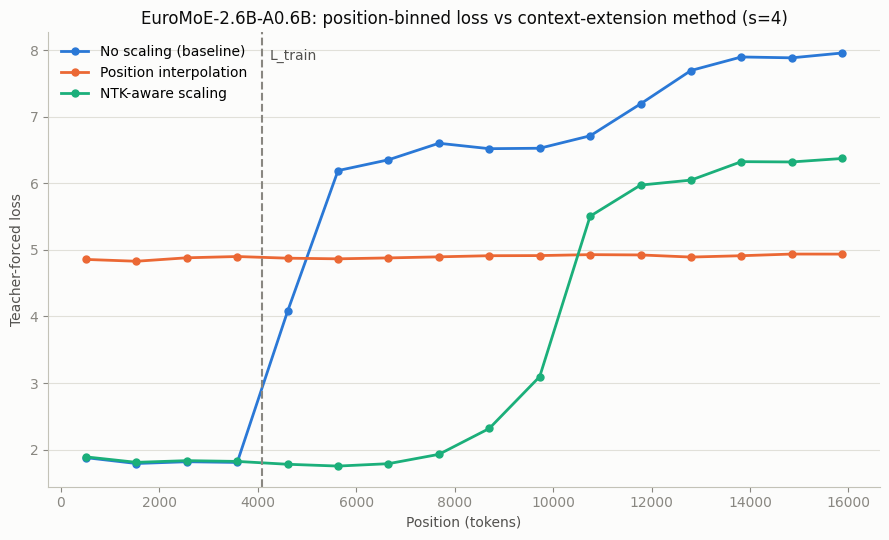

Saved to /kaggle/working/position_binned_loss.png


In [33]:
import json
import matplotlib.pyplot as plt

with open("/kaggle/working/position_binned_loss_results.json") as f:
    all_results = json.load(f)

BIN_SIZE = cfg.max_position_embeddings // 4 
N_BINS = 16
bin_centers = [(i + 0.5) * BIN_SIZE for i in range(N_BINS)]
L_TRAIN = cfg.max_position_embeddings  

colors = {
    "none": "#2a78d6",                     
    "position_interpolation": "#eb6834",   
    "ntk_aware": "#1baf7a",                
}
labels = {
    "none": "No scaling (baseline)",
    "position_interpolation": "Position interpolation",
    "ntk_aware": "NTK-aware scaling",
}

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for mode in ["none", "position_interpolation", "ntk_aware"]:
    ax.plot(
        bin_centers, all_results[mode]["mean_loss_per_bin"],
        color=colors[mode], linewidth=2, label=labels[mode],
        marker="o", markersize=5,
    )

ax.axvline(L_TRAIN, color="#898781", linestyle="--", linewidth=1.5)
ax.text(L_TRAIN + 150, ax.get_ylim()[1] * 0.95, "L_train", color="#52514e", fontsize=10)

ax.set_xlabel("Position (tokens)", color="#52514e")
ax.set_ylabel("Teacher-forced loss", color="#52514e")
ax.set_title("EuroMoE-2.6B-A0.6B: position-binned loss vs context-extension method (s=4)", color="#0b0b0b")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("/kaggle/working/position_binned_loss.png", dpi=150, facecolor="#fcfcfb")
plt.show()
print("Saved to /kaggle/working/position_binned_loss.png")

# Passkey Retrieval

In [44]:
import random
from transformers.cache_utils import DynamicCache

PASSKEY_TEMPLATE = "Магічний код: {key}. Запам'ятай цей код: {key}."
QUESTION = "\n\nЯкий магічний код було згадано вище? Дай відповідь лише числом.\nМагічний код:"

def build_passkey_prompt(tokenizer, filler_text, target_len, depth_frac, key):
    passkey_sentence = PASSKEY_TEMPLATE.format(key=key)
    passkey_ids = tokenizer(passkey_sentence, add_special_tokens=False)["input_ids"]
    question_ids = tokenizer(QUESTION, add_special_tokens=False)["input_ids"]
    filler_ids = tokenizer(filler_text, add_special_tokens=False, truncation=False)["input_ids"]

    bos = [tokenizer.bos_token_id] if tokenizer.bos_token_id is not None else []
    reserve = len(bos) + len(passkey_ids) + len(question_ids)
    filler_budget = target_len - reserve
    insert_pos = int(depth_frac * filler_budget)

    final_ids = bos + filler_ids[:insert_pos] + passkey_ids + filler_ids[insert_pos:filler_budget] + question_ids
    return final_ids[:target_len]


@torch.no_grad()
def manual_generate_passkey(model, input_ids, attention_mask, max_new_tokens=10, eos_token_id=None):
    device = input_ids.device
    prompt_len = input_ids.shape[1]

    model.config._attn_implementation = "gqa_safe_sdpa"
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        past_key_values=DynamicCache(),
        use_cache=True,
        logits_to_keep=1,
    )
    past_key_values = outputs.past_key_values
    next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)

    generated = [next_token]
    cur_attention_mask = torch.cat([attention_mask, torch.ones_like(next_token)], dim=1)

    model.config._attn_implementation = "sdpa"
    cache_position = torch.tensor([prompt_len], device=device)

    for _ in range(max_new_tokens - 1):
        outputs = model(
            input_ids=next_token,
            attention_mask=cur_attention_mask,
            past_key_values=past_key_values,
            use_cache=True,
            cache_position=cache_position,
        )
        past_key_values = outputs.past_key_values
        next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated.append(next_token)
        cur_attention_mask = torch.cat([cur_attention_mask, torch.ones_like(next_token)], dim=1)
        cache_position = cache_position + 1

        if eos_token_id is not None and (next_token == eos_token_id).all():
            break

    return torch.cat(generated, dim=1)


@torch.no_grad()
def run_passkey_test(model, tokenizer, filler_text, target_len, depth_frac, device="cuda"):
    key = "".join(str(random.randint(0, 9)) for _ in range(5))
    input_ids = torch.tensor(
        build_passkey_prompt(tokenizer, filler_text, target_len, depth_frac, key),
        device=device,
    ).unsqueeze(0)
    attention_mask = torch.ones_like(input_ids)

    with sdpa_kernel([SDPBackend.EFFICIENT_ATTENTION, SDPBackend.MATH]):
        new_tokens = manual_generate_passkey(
            model, input_ids, attention_mask,
            max_new_tokens=10, eos_token_id=tokenizer.eos_token_id,
        )
    generated_text = tokenizer.decode(new_tokens[0], skip_special_tokens=True)
    correct = key in generated_text
    return correct, key, generated_text

## Smoke Test

In [45]:
set_rope_scaling(model, "none", S, BASE, DIM)

t0 = time.time()
for i in range(3):
    filler_text = docs[i]["text"]
    correct, key, gen_text = run_passkey_test(model, tokenizer, filler_text, target_len=cfg.max_position_embeddings, depth_frac=0.5)
    print(f"trial {i}: key={key}, generated={gen_text!r}, correct={correct}")
elapsed = time.time() - t0
print(f"\n3 trials in {elapsed:.1f}s -> {elapsed/3:.1f}s per trial")

trial 0: key=70106, generated="70106. Запам'", correct=True
trial 1: key=51333, generated='111111111', correct=False
trial 2: key=87262, generated='111111111', correct=False

3 trials in 3.1s -> 1.0s per trial


## Full run

In [46]:
import time
import random
import json

LENGTHS = [cfg.max_position_embeddings, 2 * cfg.max_position_embeddings, 4 * cfg.max_position_embeddings]  # 4096, 8192, 16384
DEPTHS = [0.10, 0.50, 0.90]
N_TRIALS = 5
modes = ["none", "position_interpolation", "ntk_aware"]

passkey_results = {}

t_start = time.time()
for mode in modes:
    set_rope_scaling(model, mode, S, BASE, DIM)
    passkey_results[mode] = {}
    for length in LENGTHS:
        for depth in DEPTHS:
            correct_count = 0
            for trial in range(N_TRIALS):
                filler_doc = docs[random.randrange(len(docs))]
                correct, key, gen_text = run_passkey_test(model, tokenizer, filler_doc["text"], length, depth)
                correct_count += int(correct)
            accuracy = correct_count / N_TRIALS
            passkey_results[mode][f"len={length}_depth={depth}"] = accuracy
            print(f"[{mode}] len={length} depth={depth}: {correct_count}/{N_TRIALS} = {accuracy:.2f}")

print(f"\nTotal passkey sweep time: {(time.time()-t_start)/60:.1f} min")

model.config._attn_implementation = "gqa_safe_sdpa"  

with open("/kaggle/working/passkey_results.json", "w") as f:
    json.dump(passkey_results, f, indent=2)
print("Saved to /kaggle/working/passkey_results.json")

[none] len=4096 depth=0.1: 2/5 = 0.40
[none] len=4096 depth=0.5: 3/5 = 0.60
[none] len=4096 depth=0.9: 5/5 = 1.00
[none] len=8192 depth=0.1: 0/5 = 0.00
[none] len=8192 depth=0.5: 0/5 = 0.00
[none] len=8192 depth=0.9: 0/5 = 0.00
[none] len=16384 depth=0.1: 0/5 = 0.00
[none] len=16384 depth=0.5: 0/5 = 0.00
[none] len=16384 depth=0.9: 0/5 = 0.00
[position_interpolation] len=4096 depth=0.1: 0/5 = 0.00
[position_interpolation] len=4096 depth=0.5: 0/5 = 0.00
[position_interpolation] len=4096 depth=0.9: 0/5 = 0.00
[position_interpolation] len=8192 depth=0.1: 0/5 = 0.00
[position_interpolation] len=8192 depth=0.5: 0/5 = 0.00
[position_interpolation] len=8192 depth=0.9: 0/5 = 0.00
[position_interpolation] len=16384 depth=0.1: 0/5 = 0.00
[position_interpolation] len=16384 depth=0.5: 0/5 = 0.00
[position_interpolation] len=16384 depth=0.9: 0/5 = 0.00
[ntk_aware] len=4096 depth=0.1: 5/5 = 1.00
[ntk_aware] len=4096 depth=0.5: 1/5 = 0.20
[ntk_aware] len=4096 depth=0.9: 5/5 = 1.00
[ntk_aware] len=819